# 虚拟相机归一化：前后图像可视化

这个 notebook **只做读取和可视化**，不会修改 Dataset、模型、Loss、训练配置，也不会覆盖任何图像或 CSV。它直接加载 `modelv1/data/virtual_camera.py` 中的共享虚拟相机实现，同时绕过训练包初始化，避免无关的 PyTorch/OpenMP 运行时进入可视化内核。

图像流程：

`原始畸变图像 → 去畸变 → H = K_N S R_{N←C} K_C^{-1} → 归一化人脸 → 在同一 N 坐标系裁剪双眼`

## 必要参数

| 参数 | 类型 | 当前来源 | 作用 |
|---|---|---|---|
| `K_C` | 全相机共享，3×3 | `CROSSGAZE_CAMERA_MATRIX` | 真实相机内参 |
| `D_C` | 全相机共享 | `CROSSGAZE_DIST_COEFFS` | 真实相机畸变参数 |
| `R_C_H` | 每帧，3×3 | PnP CSV 的 `rotation_00...22` | 头部/PnP 坐标到真实相机坐标的旋转 |
| `c_C` | 每帧，3维毫米 | PnP CSV 的 `tvec_x/y/z_mm` | 真实相机坐标中的脸中心；当前采用 PnP `tvec` |
| 四个眼角像素 | 每帧 | MediaPipe PnP landmark CSV | 在归一化人脸上定位并裁剪双眼 |
| `W_N, H_N` | 全数据固定 | 默认 224×224 | 虚拟相机输出分辨率 |
| `f_N` | 全数据固定 | 默认 480 px | 虚拟相机焦距，决定归一化画面视场 |
| `d_N` | 全数据固定 | 默认 600 mm | 相机到脸的统一等效距离 |
| 眼睛尺寸/跨度 | 全数据固定 | 默认 60×36、`span=1.8` | 从共享归一化人脸裁剪眼睛 |

> 相机**外参**不参与这一步图像归一化。这里需要的是脸相对于当前相机的 PnP 几何；真实相机到世界/桌面的外参，应在之后的 gaze 方向还原与 UV 候选几何中使用。

In [17]:
from __future__ import annotations

import csv
import importlib.util
import sys
from pathlib import Path

# 必须在导入 OpenCV 前检查。若复用了已经运行过训练代码的 kernel，
# torch 与 cv2 可能分别带入一份 Intel OpenMP，从而让进程直接退出。
if 'torch' in sys.modules:
    raise RuntimeError(
        '当前 kernel 已加载 PyTorch。请执行 Restart Kernel，'
        '然后只运行这个 notebook，不要先运行训练 notebook。'
    )

import cv2
import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_REVISION = 'openmp-safe-random4-v3'

# 同时兼容从仓库根目录或 notebooks/ 目录启动。
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'modelv1').is_dir():
    if (PROJECT_ROOT.parent / 'modelv1').is_dir():
        PROJECT_ROOT = PROJECT_ROOT.parent
    else:
        raise RuntimeError('找不到仓库根目录：请从 ModelV1 或 ModelV1/notebooks 启动 notebook。')

# 不使用 `from modelv1.data...`：modelv1.data.__init__ 会加载 Dataset/PyTorch，
# 对这个纯 NumPy/OpenCV notebook 没有必要，并可能与 OpenCV 的 OpenMP 冲突。
module_path = PROJECT_ROOT / 'modelv1/data/virtual_camera.py'
module_spec = importlib.util.spec_from_file_location(
    '_modelv1_virtual_camera_standalone', module_path
)
if module_spec is None or module_spec.loader is None:
    raise ImportError(f'无法加载虚拟相机模块：{module_path}')
virtual_camera_module = importlib.util.module_from_spec(module_spec)
sys.modules[module_spec.name] = virtual_camera_module
module_spec.loader.exec_module(virtual_camera_module)

CameraCalibration = virtual_camera_module.CameraCalibration
EyeCropConfig = virtual_camera_module.EyeCropConfig
VirtualCameraConfig = virtual_camera_module.VirtualCameraConfig
build_virtual_camera_transform = virtual_camera_module.build_virtual_camera_transform
render_shared_normalized_inputs = virtual_camera_module.render_shared_normalized_inputs

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False
print('PROJECT_ROOT =', PROJECT_ROOT)
print('NOTEBOOK_REVISION =', NOTEBOOK_REVISION)
print('训练栈是否被本 notebook 导入：torch =', 'torch' in sys.modules)

PROJECT_ROOT = D:\GithubCode\ModelV1
NOTEBOOK_REVISION = openmp-safe-random4-v3
训练栈是否被本 notebook 导入：torch = False


## 1. 参数配置

通常只需要在这个单元修改数据路径、`MANUAL_SAMPLE_IDS` 和虚拟相机参数。默认从所有 PnP/landmark 有效且源图像存在的样本中随机抽取 4 张；也可以手动填写任意 4 个 `sample_id`。

In [18]:
# ---------- 数据路径 ----------
DATASET_CSVS = [
    PROJECT_ROOT / 'data/processed/modelv1_dataset3.csv',
    PROJECT_ROOT / 'data/processed/modelv1_dataset4.csv',
]
DEPTH_PRIOR_CSV = PROJECT_ROOT / 'data/processed/depth_priors_deca_crop_v1.csv'
LANDMARK_CSVS = [
    PROJECT_ROOT / 'data/processed/mediapipe_pnp_landmarks_3.csv',
    PROJECT_ROOT / 'data/processed/mediapipe_pnp_landmarks_4.csv',
]

# ---------- 可视化样本选择 ----------
NUM_VISUALIZATION_SAMPLES = 4

# 留空时从 dataset 3/4 的全部有效样本中随机抽取 4 张。
# 如果希望指定图像，请在列表中填写恰好 4 个完整 sample_id，例如：
# MANUAL_SAMPLE_IDS = [
#     'dataset_dual_rigid_body_3/img_20260422_151156_00000',
#     'dataset_dual_rigid_body_3/img_20260422_151217_00001',
#     'dataset_dual_rigid_body_4/img_20260423_094136_00000',
#     'dataset_dual_rigid_body_4/img_20260423_094142_00001',
# ]
MANUAL_SAMPLE_IDS = []

# None 表示每次运行重新随机选择；设成整数（例如 42）可复现同一组结果。
RANDOM_SEED = 42

# ---------- 真实相机：所有相机内参一致 ----------
# 数值与 modelv1/depth_prior/pnp.py 中的 CrossGaze 标定一致。这里显式配置，
# 避免为了两个常量导入包含 PyTorch/DECA 的 modelv1.depth_prior 包。
CROSSGAZE_CAMERA_MATRIX = np.array([
    [1367.8584, 0.0, 957.9159],
    [0.0, 1369.0087, 543.3381],
    [0.0, 0.0, 1.0],
], dtype=np.float64)
CROSSGAZE_DIST_COEFFS = np.array([
    1.78483784e-01,
    -5.90774600e-01,
    -5.11403240e-04,
    -1.08456025e-03,
    5.95053471e-01,
], dtype=np.float64)

CALIBRATION = CameraCalibration(
    camera_matrix=np.asarray(CROSSGAZE_CAMERA_MATRIX, dtype=np.float64),
    distortion_coefficients=np.asarray(CROSSGAZE_DIST_COEFFS, dtype=np.float64),
)

# ---------- 所有样本共享的虚拟相机 ----------
VIRTUAL_CAMERA = VirtualCameraConfig(
    output_width=224,
    output_height=224,
    focal_length_px=480.0,
    distance_mm=600.0,
)

# 双眼从同一张归一化人脸中裁剪，不建立单独的眼睛虚拟相机。
EYE_CROP = EyeCropConfig(
    output_width=60,
    output_height=36,
    horizontal_span_scale=1.8,
)

print('K_C =\n', CALIBRATION.camera_matrix)
print('D_C =', CALIBRATION.distortion_coefficients)
print('K_N =\n', VIRTUAL_CAMERA.camera_matrix)
print('虚拟距离 =', VIRTUAL_CAMERA.distance_mm, 'mm')
print('人脸输出 =', (VIRTUAL_CAMERA.output_width, VIRTUAL_CAMERA.output_height))
print('眼睛输出 =', (EYE_CROP.output_width, EYE_CROP.output_height))

K_C =
 [[1367.8584    0.      957.9159]
 [   0.     1369.0087  543.3381]
 [   0.        0.        1.    ]]
D_C = [ 0.17848 -0.59077 -0.00051 -0.00108  0.59505]
K_N =
 [[480.   0. 112.]
 [  0. 480. 112.]
 [  0.   0.   1.]]
虚拟距离 = 600.0 mm
人脸输出 = (224, 224)
眼睛输出 = (60, 36)


## 2. 读取 CSV 并构造归一化样本

In [19]:
def read_rows(paths):
    rows = []
    for path in paths:
        with Path(path).open('r', encoding='utf-8-sig', newline='') as handle:
            rows.extend(dict(row) for row in csv.DictReader(handle))
    return rows


def unique_index(rows, name):
    result = {}
    for row in rows:
        sample_id = row.get('sample_id', '').strip()
        if not sample_id:
            raise ValueError(f'{name} 中存在缺少 sample_id 的行')
        if sample_id in result:
            raise ValueError(f'{name} 中 sample_id 重复：{sample_id}')
        result[sample_id] = row
    return result


def read_image(path):
    # np.fromfile + imdecode 对 Windows 中文路径更稳健。
    path = Path(path)
    image = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError(f'图像读取失败：{path}')
    return image


def read_optional_image(raw_path):
    if not raw_path:
        return None
    path = Path(raw_path)
    return read_image(path) if path.is_file() else None


def rgb(image_bgr):
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def value(row, column):
    result = float(row[column])
    if not np.isfinite(result):
        raise ValueError(f'{column} 不是有限数值')
    return result


def choose_source_path(dataset_row, landmark_row, depth_row):
    candidates = [
        row.get('source_image_path', '').strip()
        for row in (dataset_row, landmark_row, depth_row)
    ]
    for candidate in candidates:
        if candidate and Path(candidate).is_file():
            return Path(candidate)
    raise FileNotFoundError(f'找不到源图像：{candidates}')


DATASET_ROWS = read_rows(DATASET_CSVS)
DATASET_INDEX = unique_index(DATASET_ROWS, 'dataset CSV')
DEPTH_INDEX = unique_index(read_rows([DEPTH_PRIOR_CSV]), 'depth-prior CSV')
LANDMARK_INDEX = unique_index(read_rows(LANDMARK_CSVS), 'landmark CSV')
print(f'dataset={len(DATASET_INDEX)}, depth={len(DEPTH_INDEX)}, landmark={len(LANDMARK_INDEX)}')

dataset=797, depth=1133, landmark=797


In [20]:
def valid_sample_ids():
    valid = []
    for row in DATASET_ROWS:
        sample_id = row['sample_id'].strip()
        depth = DEPTH_INDEX.get(sample_id)
        landmarks = LANDMARK_INDEX.get(sample_id)
        if depth is None or landmarks is None:
            continue
        depth_status = depth.get('depth_prior_status', depth.get('status', '')).lower()
        if depth_status != 'success' or landmarks.get('status', '').lower() != 'success':
            continue
        try:
            choose_source_path(row, landmarks, depth)
        except FileNotFoundError:
            continue
        valid.append(sample_id)
    return valid


def select_sample_ids():
    candidates = valid_sample_ids()
    if len(candidates) < NUM_VISUALIZATION_SAMPLES:
        raise ValueError(
            f'有效样本只有 {len(candidates)} 个，无法选择 {NUM_VISUALIZATION_SAMPLES} 个。'
        )

    if MANUAL_SAMPLE_IDS:
        selected = [str(sample_id).strip() for sample_id in MANUAL_SAMPLE_IDS]
        if len(selected) != NUM_VISUALIZATION_SAMPLES:
            raise ValueError(
                f'MANUAL_SAMPLE_IDS 必须恰好包含 {NUM_VISUALIZATION_SAMPLES} 个 sample_id。'
            )
        if len(set(selected)) != len(selected):
            raise ValueError('MANUAL_SAMPLE_IDS 中不能包含重复 sample_id。')
        invalid = [sample_id for sample_id in selected if sample_id not in candidates]
        if invalid:
            raise ValueError(f'以下手动样本不存在或 PnP/landmark/图像无效：{invalid}')
        return selected, 'manual'

    rng = np.random.default_rng(RANDOM_SEED)
    indices = rng.choice(
        len(candidates), size=NUM_VISUALIZATION_SAMPLES, replace=False
    )
    selected = [candidates[int(index)] for index in indices]
    return selected, f'random(seed={RANDOM_SEED})'


def build_visualization_sample(sample_id):
    dataset_row = DATASET_INDEX[sample_id]
    depth_row = DEPTH_INDEX[sample_id]
    landmark_row = LANDMARK_INDEX[sample_id]
    source_path = choose_source_path(dataset_row, landmark_row, depth_row)
    source = read_image(source_path)

    rotation_c_from_h = np.array([
        [value(depth_row, f'rotation_{r}{c}') for c in range(3)]
        for r in range(3)
    ], dtype=np.float64)
    face_center_c_mm = np.array(
        [value(depth_row, f'tvec_{axis}_mm') for axis in 'xyz'],
        dtype=np.float64,
    )
    left_source = np.array([
        [value(landmark_row, 'left_eye_outer_x'), value(landmark_row, 'left_eye_outer_y')],
        [value(landmark_row, 'left_eye_inner_x'), value(landmark_row, 'left_eye_inner_y')],
    ])
    right_source = np.array([
        [value(landmark_row, 'right_eye_inner_x'), value(landmark_row, 'right_eye_inner_y')],
        [value(landmark_row, 'right_eye_outer_x'), value(landmark_row, 'right_eye_outer_y')],
    ])

    transform = build_virtual_camera_transform(
        calibration=CALIBRATION,
        head_rotation_camera_from_head=rotation_c_from_h,
        face_center_camera_mm=face_center_c_mm,
        config=VIRTUAL_CAMERA,
    )
    normalized = render_shared_normalized_inputs(
        source_image=source,
        calibration=CALIBRATION,
        transform=transform,
        left_eye_corners_source_xy=left_source,
        right_eye_corners_source_xy=right_source,
        eye_crop_config=EYE_CROP,
    )

    # 将相机坐标中的 PnP 脸中心投影回带畸变原图，仅用于标记。
    center_pixel, _ = cv2.projectPoints(
        face_center_c_mm.reshape(1, 3),
        np.zeros(3),
        np.zeros(3),
        CALIBRATION.camera_matrix,
        CALIBRATION.distortion_coefficients,
    )

    return {
        'sample_id': sample_id,
        'dataset_row': dataset_row,
        'source_path': source_path,
        'source': source,
        'old_face': read_optional_image(dataset_row.get('face_path', '')),
        'old_left_eye': read_optional_image(dataset_row.get('left_eye_path', '')),
        'old_right_eye': read_optional_image(dataset_row.get('right_eye_path', '')),
        'left_source': left_source,
        'right_source': right_source,
        'face_center_pixel': center_pixel.reshape(2),
        'face_center_c_mm': face_center_c_mm,
        'rotation_c_from_h': rotation_c_from_h,
        'transform': transform,
        'normalized': normalized,
    }


SELECTED_SAMPLE_IDS, SELECTION_MODE = select_sample_ids()
SAMPLES = [build_visualization_sample(sample_id) for sample_id in SELECTED_SAMPLE_IDS]

print(f'选择方式：{SELECTION_MODE}')
print(f'从 {len(valid_sample_ids())} 个有效候选中选择以下 4 张图像：')
for sample in SAMPLES:
    print(' -', sample['sample_id'])

选择方式：random(seed=42)
从 797 个有效候选中选择以下 4 张图像：
 - dataset_dual_rigid_body_3/img_20260422_153435_00469
 - dataset_dual_rigid_body_3/img_20260422_151655_00082
 - dataset_dual_rigid_body_4/img_20260423_094648_00092
 - dataset_dual_rigid_body_4/img_20260423_095534_00211


## 3. 原图、旧裁剪与虚拟相机归一化结果

原图中的蓝点是四个眼角，黄色叉号是 PnP `tvec` 对应的脸中心投影。归一化图中的白色十字是固定虚拟相机的图像中心。

C:\Users\Max\AppData\Local\Temp\ipykernel_23724\1644314828.py:57: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from current font.
  fig.tight_layout(rect=(0, 0, 1, 0.98))
C:\Users\Max\AppData\Local\Temp\ipykernel_23724\1644314828.py:57: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from current font.
  fig.tight_layout(rect=(0, 0, 1, 0.98))
C:\Users\Max\AppData\Local\Temp\ipykernel_23724\1644314828.py:57: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from current font.
  fig.tight_layout(rect=(0, 0, 1, 0.98))
C:\Users\Max\AppData\Local\Temp\ipykernel_23724\1644314828.py:57: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from current font.
  fig.tight_layout(rect=(0, 0, 1, 0.98))
C:\Users\Max\AppData\Local\Temp\ipykernel_23724\1644314828.py:57: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from current font.
  fig.tight_layout(rect=(0, 0, 1, 0.98))
C:\Users\Max\AppData\Local\Temp\ipykernel_23724\164

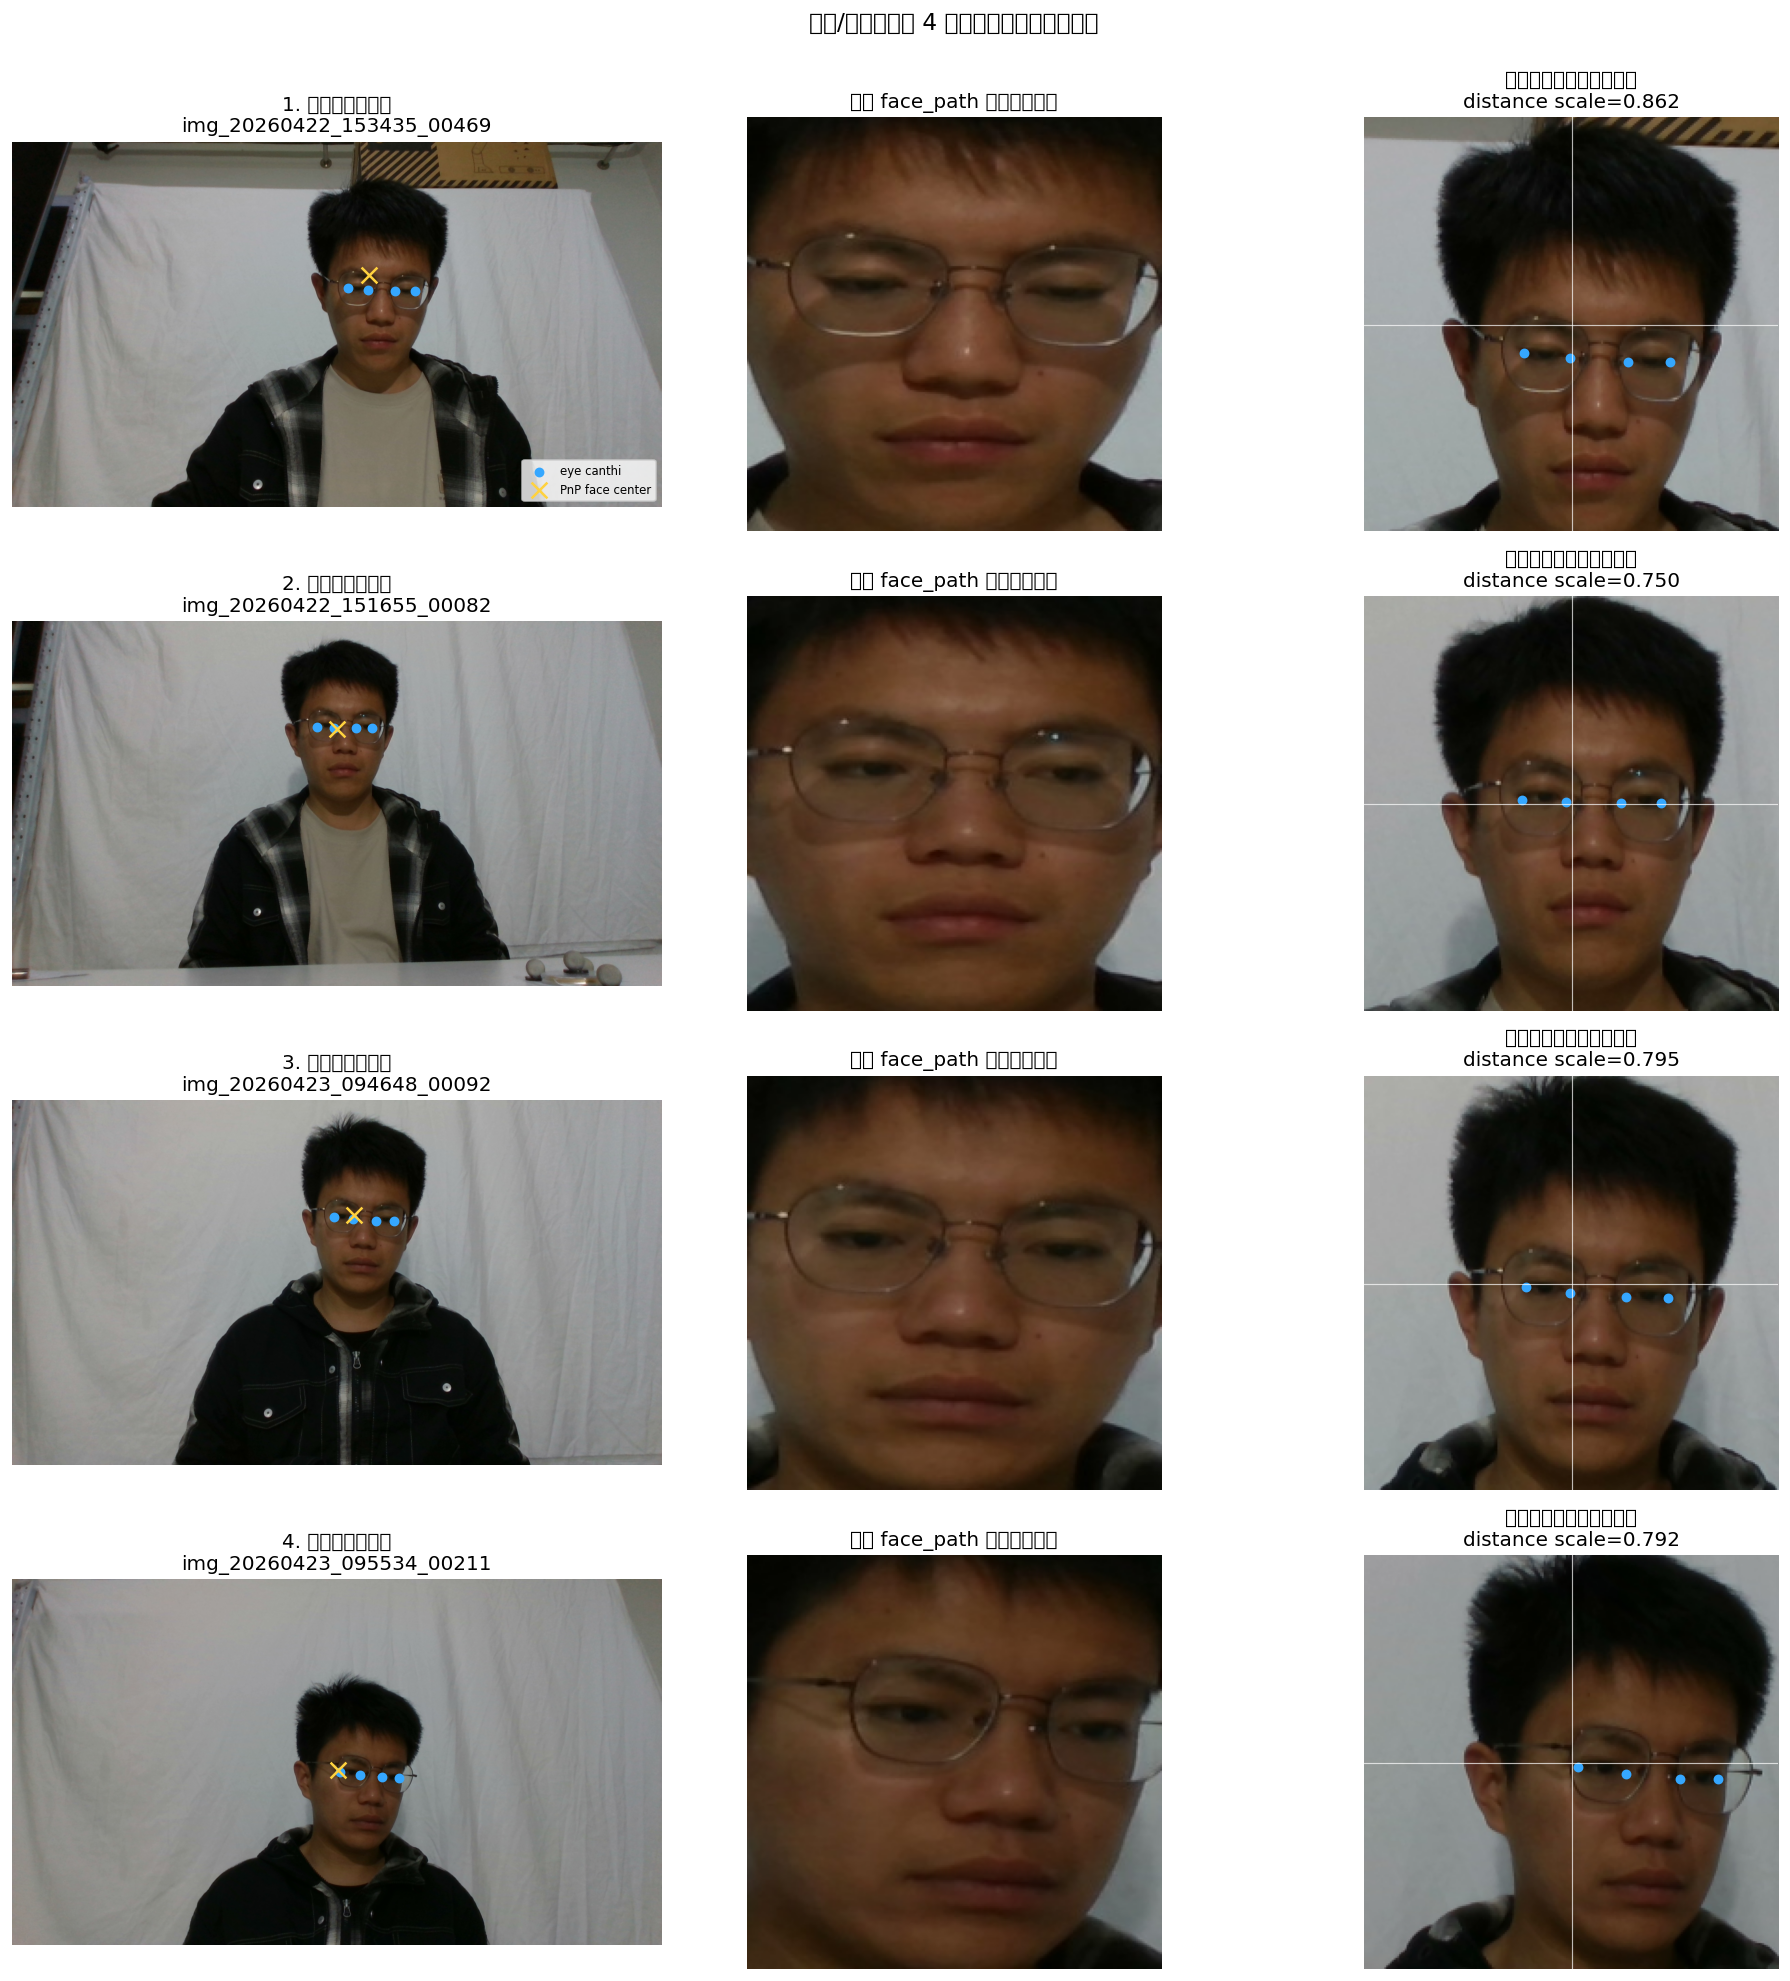

In [21]:
def show_image_or_missing(axis, image, title):
    axis.set_title(title)
    axis.axis('off')
    if image is None:
        axis.text(0.5, 0.5, '文件不存在', ha='center', va='center')
    else:
        axis.imshow(rgb(image))


num_samples = len(SAMPLES)
fig, axes = plt.subplots(num_samples, 3, figsize=(16, 4.2 * num_samples), squeeze=False)

for row_index, sample in enumerate(SAMPLES):
    normalized = sample['normalized']
    transform = sample['transform']
    source_axis, old_face_axis, normalized_axis = axes[row_index]
    short_id = sample['sample_id'].split('/')[-1]

    source_axis.imshow(rgb(sample['source']))
    corners = np.concatenate([sample['left_source'], sample['right_source']], axis=0)
    source_axis.scatter(corners[:, 0], corners[:, 1], s=24, c='#35a7ff', label='eye canthi')
    center = sample['face_center_pixel']
    source_axis.scatter(
        center[0], center[1], s=90, c='#ffd23f', marker='x', label='PnP face center'
    )
    source_axis.set_title(f'{row_index + 1}. 归一化前：原图\n{short_id}')
    source_axis.axis('off')
    if row_index == 0:
        source_axis.legend(loc='lower right', fontsize=7)

    show_image_or_missing(old_face_axis, sample['old_face'], '现有 face_path 裁剪（对照）')

    normalized_axis.imshow(rgb(normalized.face_image))
    normalized_axis.scatter(
        normalized.left_eye_corners_normalized[:, 0],
        normalized.left_eye_corners_normalized[:, 1],
        s=24, c='#35a7ff',
    )
    normalized_axis.scatter(
        normalized.right_eye_corners_normalized[:, 0],
        normalized.right_eye_corners_normalized[:, 1],
        s=24, c='#35a7ff',
    )
    normalized_axis.axvline(
        VIRTUAL_CAMERA.output_width / 2, color='white', lw=0.7, alpha=0.7
    )
    normalized_axis.axhline(
        VIRTUAL_CAMERA.output_height / 2, color='white', lw=0.7, alpha=0.7
    )
    normalized_axis.set_title(
        '归一化后：共享虚拟相机\n'
        f"distance scale={transform.distance_scale:.3f}"
    )
    normalized_axis.axis('off')

fig.suptitle('随机/手动选择的 4 张图像：归一化前后对比', fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

## 4. 双眼裁剪前后对比

下排双眼来自同一张归一化人脸，因此它们共享完全相同的虚拟相机坐标系。

C:\Users\Max\AppData\Local\Temp\ipykernel_23724\4233143869.py:15: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from current font.
  fig.tight_layout(rect=(0, 0, 1, 0.97))
C:\Users\Max\AppData\Local\Temp\ipykernel_23724\4233143869.py:15: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from current font.
  fig.tight_layout(rect=(0, 0, 1, 0.97))
C:\Users\Max\AppData\Local\Temp\ipykernel_23724\4233143869.py:15: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from current font.
  fig.tight_layout(rect=(0, 0, 1, 0.97))
C:\Users\Max\AppData\Local\Temp\ipykernel_23724\4233143869.py:15: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from current font.
  fig.tight_layout(rect=(0, 0, 1, 0.97))
C:\Users\Max\AppData\Local\Temp\ipykernel_23724\4233143869.py:15: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from current font.
  fig.tight_layout(rect=(0, 0, 1, 0.97))
C:\Users\Max\AppData\Local\Temp\ipykernel_23724\423

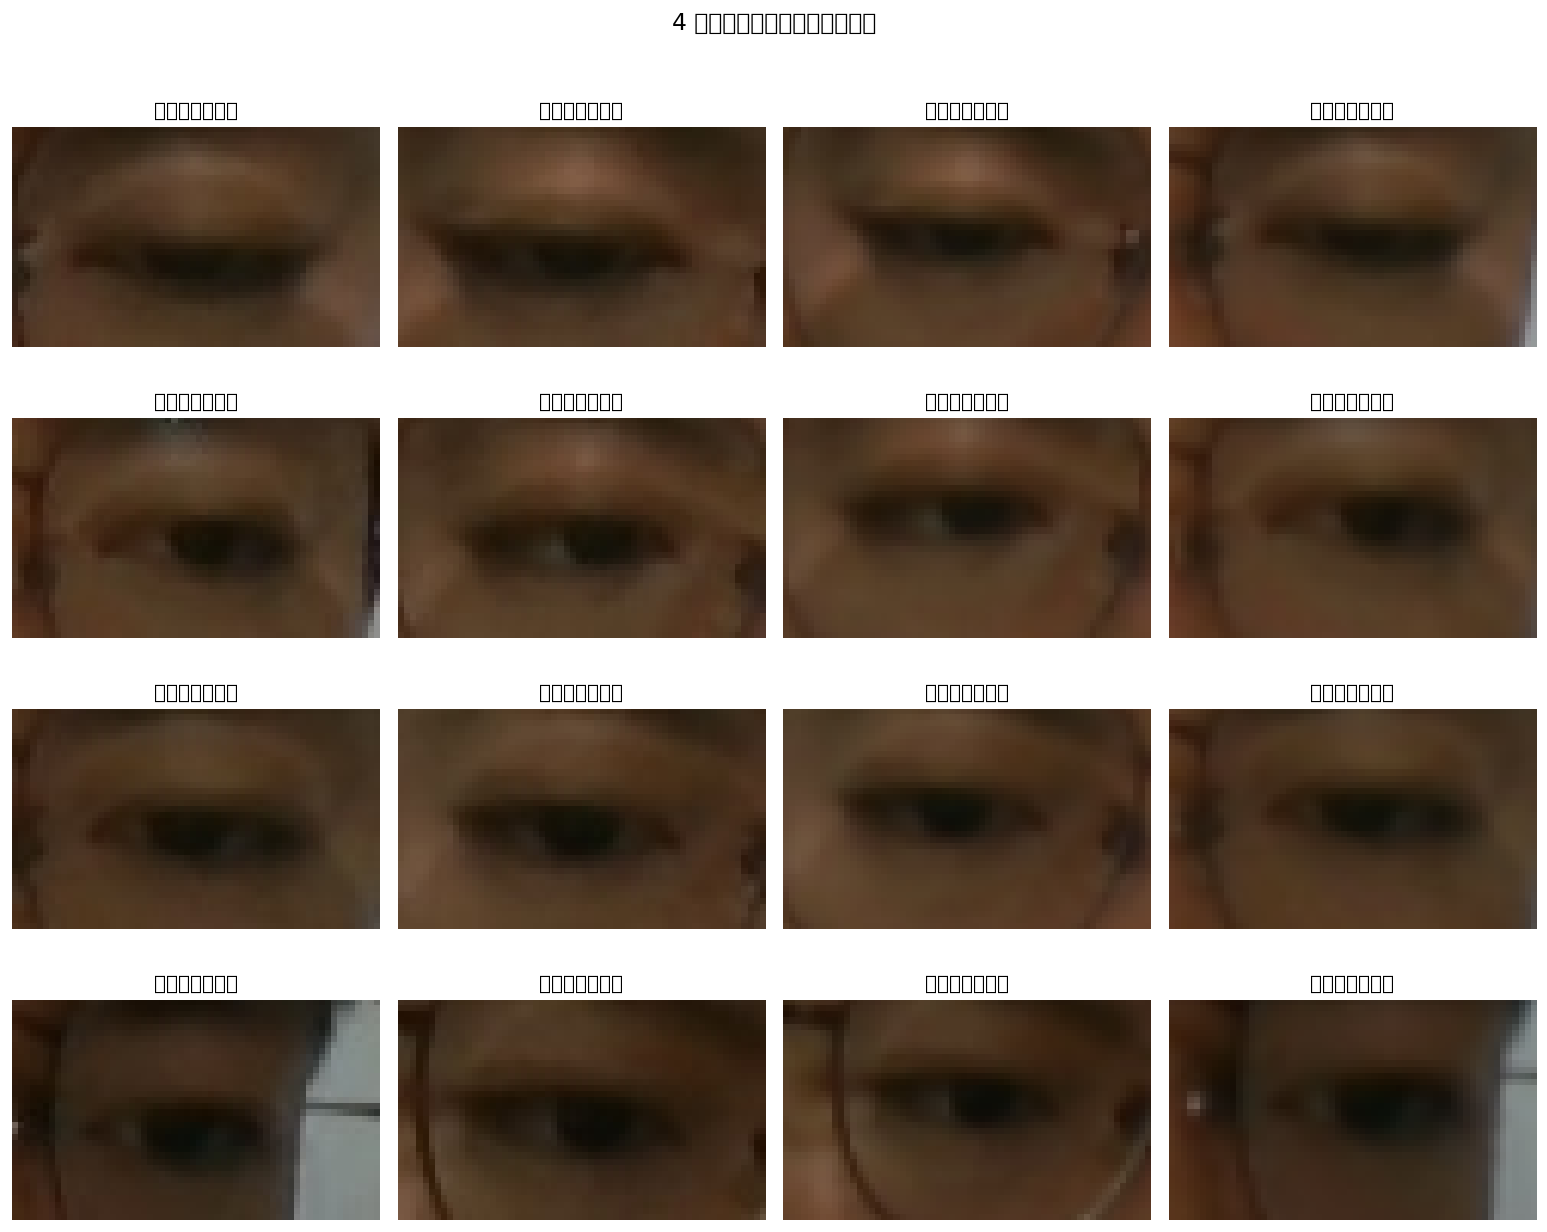

In [22]:
num_samples = len(SAMPLES)
fig, axes = plt.subplots(num_samples, 4, figsize=(13, 2.7 * num_samples), squeeze=False)

for row_index, sample in enumerate(SAMPLES):
    normalized = sample['normalized']
    show_image_or_missing(axes[row_index, 0], sample['old_left_eye'], '归一化前：左眼')
    show_image_or_missing(axes[row_index, 1], sample['old_right_eye'], '归一化前：右眼')
    show_image_or_missing(axes[row_index, 2], normalized.left_eye.image, '归一化后：左眼')
    show_image_or_missing(axes[row_index, 3], normalized.right_eye.image, '归一化后：右眼')
    axes[row_index, 0].set_ylabel(
        f"{row_index + 1}. {sample['sample_id'].split('/')[-1]}", fontsize=8
    )

fig.suptitle('4 张图像的双眼归一化前后对比', fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

## 5. 检查每个样本的几何参数

- `R_N_from_C`：真实相机方向旋转到虚拟相机方向。
- `R_N_from_H`：归一化图像对应的头部姿态。
- `H_N_from_undistorted`：去畸变图像到归一化图像的单应矩阵。
- `distance_scale`：只属于图像重投影。转换 gaze 方向时只用旋转，不能乘这个缩放。

In [23]:
np.set_printoptions(precision=5, suppress=True)
for sample in SAMPLES:
    transform = sample['transform']
    print('\n' + '=' * 90)
    print(sample['sample_id'])
    print('face_center_C_mm =', sample['face_center_c_mm'])
    print('distance_scale =', transform.distance_scale)
    print('R_N_from_C =\n', transform.rotation_normalized_from_camera)
    print('R_N_from_H =\n', transform.head_rotation_normalized_from_head)
    print('H_N_from_undistorted =\n', transform.homography_normalized_from_undistorted)

    # 示例：真实相机坐标中的单位 gaze 方向如何变到虚拟相机。
    gaze_c_example = np.array([0.0, 0.0, 1.0])
    gaze_n_example = transform.direction_camera_to_normalized(gaze_c_example)
    gaze_c_roundtrip = transform.direction_normalized_to_camera(gaze_n_example)
    print('g_C example -> g_N =', gaze_n_example)
    print('g_N -> g_C roundtrip =', gaze_c_roundtrip)


dataset_dual_rigid_body_3/img_20260422_153435_00469
face_center_C_mm = [ 49.49615 -75.29442 690.39855]
distance_scale = 0.8617547965917677
R_N_from_C =
 [[ 0.99738 -0.00585 -0.07214]
 [ 0.0136   0.99412  0.10744]
 [ 0.07109 -0.10814  0.99159]]
R_N_from_H =
 [[ 0.99959 -0.00019  0.0285 ]
 [ 0.      -0.99998 -0.00664]
 [ 0.0285   0.00664 -0.99957]]
H_N_from_undistorted =
 [[   0.41835   -0.0114  -322.57574]
 [   0.01154    0.40176  -55.78816]
 [   0.00005   -0.00008    1.     ]]
g_C example -> g_N = [-0.07214  0.10744  0.99159]
g_N -> g_C roundtrip = [-0.  0.  1.]

dataset_dual_rigid_body_3/img_20260422_151655_00082
face_center_C_mm = [   1.10976 -128.63048  789.56681]
distance_scale = 0.7500218080895821
R_N_from_C =
 [[ 1.       0.00175 -0.00112]
 [-0.00155  0.98699  0.16079]
 [ 0.00139 -0.16079  0.98699]]
R_N_from_H =
 [[ 0.99951  0.00231  0.0312 ]
 [ 0.      -0.99727  0.07379]
 [ 0.03128 -0.07376 -0.99679]]
H_N_from_undistorted =
 [[   0.44577   -0.01175 -316.01325]
 [  -0.00058    0

## 如何调参

1. **优先固定 `distance_mm=600`**，观察不同相机/不同帧的人脸尺寸是否基本一致。
2. 人脸在 224×224 中太大、容易被截断：降低 `focal_length_px`；人脸太小：提高它。
3. `focal_length_px` 确定后应对训练、验证和测试保持一致，不能按数据集分别调。
4. 双眼上下文太少：增大 `horizontal_span_scale`；眼睛过小、包含太多皮肤：减小它。
5. 如果 PnP `tvec` 抖动明显，应先按 `reprojection_error`/`pnp_confidence` 检查坏帧，而不是通过修改虚拟相机参数掩盖 PnP 问题。
6. 当前 notebook 不生成全量数据；全量离线生成使用 `scripts/generate_virtual_camera_normalized_images.py`。